In [5]:
# 导入模块
import sys
import pandas as pd
from pathlib import Path
sys.path.append("..")
from utils.set_fonts import apply_times_with_cn
en_fp, cn_fp = apply_times_with_cn(cn_font_path=r"C:\Windows\\Fonts\\msyh.ttc")

Applied font.family: ['Times New Roman', 'Microsoft YaHei', 'DejaVu Sans']
findfont Times -> C:\Windows\Fonts\times.ttf
findfont CN -> C:\Windows\\Fonts\\msyh.ttc


In [7]:
from utils.common import (DATASETS, SEEDS, load_json, set_seed, load_data_and_info, 
                          get_per_fold_result, get_train_and_test_pos, get_gens)
from experiment.runner import run_all
from experiment.ifc_pipeline import make_ifc_cell

dataset = "framingham"
df, X, y, num_cols, cat_cols, target, datasets_info = load_data_and_info(dataset)

In [8]:
from experiment.prepare_folds import prepare_folds
from experiment.ifc_stages import train_one_stage
from hetero_vae.config import VAEConfig

seed = SEEDS[0]
set_seed(seed)

config = VAEConfig()
config.update_from_dict(
    dict(token_dim=16, kl_warmup_steps=50, beta=0.3, free_bits=0.02,
         latent_dim=16,numeric_tokenizer="linear")
)

fold_data = None

for fold_data in prepare_folds(
    X=X, y=y, dataset_name=dataset, datasets_info=datasets_info,
    seed=seed, fold_threshold=300, val_ratio=0.15,
    ):
    fold_data = fold_data

    n_pos = len(fold_data.X_train_pos)
    n_neg = len(fold_data.X_train) - n_pos
    ratio = n_neg / n_pos if n_pos > 0 else float("inf")
    n_final = (n_neg - n_pos) if ratio > 2 else n_pos

    print(f"[run]  {dataset} seed={seed} fold={fold_data.fold}")          
    results = train_one_stage(
        train_df=fold_data.X_train_pos,
        valid_df=fold_data.X_valid_pos,
        n_samples = n_final,
        config = config, 
        fold_data = fold_data,
        stage_name="v0")
    break

trainer = results.trainer
X_syn = results.X_syn
X_syn.head()

[run]  framingham seed=42 fold=1


Training Progress:   4%|▍         | 408/10000 [00:49<19:28,  8.21it/s]


早停触发(PQ准则, alpha=1.0)：epoch=409, gen_loss=10.53, progress=10.19


,male,age,education,currentSmoker,cigsPerDay,BPMeds,prevalentStroke,prevalentHyp,diabetes,totChol,sysBP,diaBP,BMI,heartRate,glucose
0,0.0,64,4.0,0.0,0,0.0,0.0,0.0,0.0,295,132.5,73.0,24.67,55,79
1,0.0,50,3.0,1.0,0,0.0,0.0,0.0,0.0,242,117.5,77.5,28.13,62,72
2,0.0,58,1.0,1.0,0,1.0,0.0,1.0,1.0,246,207.0,123.0,37.14,85,85
3,0.0,46,1.0,0.0,0,0.0,0.0,0.0,0.0,186,102.0,68.0,26.13,95,77
4,1.0,56,1.0,1.0,20,0.0,0.0,1.0,0.0,212,140.5,87.0,24.35,60,68


In [13]:
columns = fold_data.X_train_pos.columns
print(fold_data.X_train_pos[columns[15]].unique())

[0]


In [4]:
from ForestDiffusion.diffusion_with_trees_class import ForestDiffusionModel
import pandas as pd

def forestDiffusion_generate(fold_data, n_samples_list):
    model = ForestDiffusionModel(fold_data.X_train_pos.to_numpy(), n_t=10, duplicate_K=1)
    results = []
    for n in n_samples_list:
        X_syn = model.generate(batch_size=n)
        X_syn = pd.DataFrame(X_syn, columns=fold_data.X_train.columns)
        results.append(X_syn)
    
    return results

cat_indexes = [X.columns.get_loc(col) for col in fold_data.cat_cols]
print(cat_indexes)
model = ForestDiffusionModel(fold_data.X_train_pos.to_numpy(), cat_indexes=cat_indexes, n_t=10, duplicate_K=1)
X_syn = model.generate(batch_size=len(fold_data.X_train_pos))
X_syn = pd.DataFrame(X_syn, columns=X.columns)
X_syn = fold_data.processor.canonicalize(X_syn)
X_syn.head()

[0, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22]


,Gender,Age_at_diagnosis,Race,IDH1,TP53,ATRX,PTEN,EGFR,CIC,MUC16,...,FUBP1,RB1,NOTCH1,BCOR,CSMD3,SMARCA4,GRIN2A,IDH2,FAT4,PDGFRA
0,1.0,89.29,2.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
1,1.0,69.94,2.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.0,58.03,1.0,0.0,1.0,1.0,0.0,0.0,0.0,1.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
3,0.0,63.96,1.0,0.0,1.0,1.0,0.0,0.0,0.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
4,1.0,72.85,1.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0


In [12]:
print(model.X_names_before)
print(model.X_names_after)
print(model.cat_indexes)

Index(['0', '1', '2', '3', '4', '5', '6', '7', '8', '9', '10', '11', '12',
       '13', '14', '15', '16', '17', '18', '19', '20', '21', '22'],
      dtype='object')
Index(['1', '0_1.0', '2_1.0', '2_2.0', '3_1.0', '4_1.0', '5_1.0', '6_1.0',
       '7_1.0', '8_1.0', '9_1.0', '10_1.0', '11_1.0', '12_1.0', '13_1.0',
       '14_1.0', '16_1.0', '17_1.0', '18_1.0', '19_1.0', '20_1.0', '21_1.0',
       '22_1.0'],
      dtype='object')
[0, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22]


In [19]:

X_syn.head()

,male,age,education,currentSmoker,cigsPerDay,BPMeds,prevalentStroke,prevalentHyp,diabetes,totChol,sysBP,diaBP,BMI,heartRate,glucose
0,1.000000,61.257312,4.000000,1.0,0.000000,0.000000,0.109526,0.000000,1.000000,107.530426,190.623178,48.000000,56.800000,50.000000,50.000000
1,0.000000,36.000000,1.000000,0.0,15.365521,0.000000,0.228246,0.716346,0.815973,369.310592,241.534838,140.000000,16.610000,50.000000,126.970442
2,0.052949,58.641003,2.058826,0.0,2.924752,0.000000,0.000000,0.000000,0.937085,270.984237,85.500000,140.000000,30.853181,85.871390,50.000000
3,0.000000,69.642235,2.850696,0.0,60.000000,0.000000,0.919637,0.138292,0.407669,378.613255,169.755758,83.335576,16.610000,50.000000,116.714352
4,0.000000,70.000000,1.136558,0.0,13.571919,0.392358,0.085559,1.000000,0.000000,412.381833,142.530071,140.000000,29.150163,118.107477,50.000000


<Axes: xlabel='epoch'>

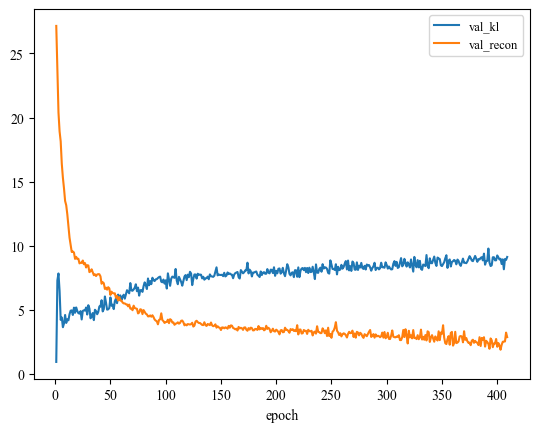

In [13]:
%matplotlib inline
import matplotlib.pyplot as plt
import pandas as pd

pd.DataFrame(trainer.history)[
    ["epoch", "val_kl", "val_recon"]
    ].plot(x="epoch")

In [5]:
from experiment.evaluate import evaluate_method, evaluate_raw
evaluate_raw(fold_data, fold_data.seed)

,Method,Dataset,Seed,Fold,Classifier,Recall,F1_score,G_mean
0,raw,framingham,42,1,SVC,0.632812,0.370709,0.657588
1,raw,framingham,42,1,MLP,0.000000,0.000000,0.000000
2,raw,framingham,42,1,XGB,0.015625,0.029851,0.124652


In [14]:
X_final = trainer.generate_samples(n_final, 1.0, True, fold_data.get_seed("sample_final"))
evaluate_method(fold_data, X_final, method_name='none_noft', random_state=fold_data.seed)

,Method,Dataset,Seed,Fold,Classifier,Recall,F1_score,G_mean
0,none_noft,framingham,42,1,SVC,0.507812,0.341207,0.612550
1,none_noft,framingham,42,1,MLP,0.398438,0.286517,0.548168
2,none_noft,framingham,42,1,XGB,0.601562,0.376528,0.656597


In [7]:
real_pos, _ = get_train_and_test_pos(dataset, 42, 1)
real_pos[datasets_info[dataset]['numerical']].describe().round(2)

,age,cigsPerDay,totChol,sysBP,diaBP,BMI,heartRate,glucose
count,439.00,439.00,439.00,439.00,439.00,439.00,439.00,439.00
mean,54.19,9.91,245.56,144.26,87.07,26.63,76.23,88.68
std,7.91,12.82,45.59,27.24,14.46,4.50,12.48,41.57
min,36.00,0.00,107.00,85.50,48.00,16.61,50.00,50.00
25%,48.00,0.00,214.00,125.75,78.00,23.82,67.50,73.00
50%,55.00,0.00,241.00,139.00,85.00,26.27,75.00,79.00
75%,60.00,20.00,272.00,158.50,95.00,28.93,83.50,88.00
max,70.00,60.00,439.00,295.00,140.00,56.80,120.00,394.00


In [8]:
X_final[datasets_info[dataset]['numerical']].describe().round(2)

,age,cigsPerDay,totChol,sysBP,diaBP,BMI,heartRate,glucose
count,2005.00,2005.00,2005.00,2005.00,2005.00,2005.00,2005.00,2005.00
mean,54.59,3.66,230.53,143.84,88.51,25.57,75.53,86.19
std,5.42,7.42,33.40,24.04,13.65,3.00,10.19,32.95
min,36.00,0.00,128.00,93.00,48.00,16.94,50.00,46.00
25%,51.00,0.00,208.00,127.00,80.00,23.70,69.00,73.00
50%,55.00,0.00,230.00,140.00,87.00,25.37,75.00,80.00
75%,58.00,0.00,252.00,155.50,96.50,27.23,80.00,89.00
max,69.00,35.00,393.00,295.00,139.50,43.73,122.00,393.00


In [ ]:
x_num_t, x_cat_t = trainer.encode_dataframe(fold_data.X_train_pos)
z_mean, z_logvar = trainer.model.encoder(x_num_t, x_cat_t)
z_mean.std(dim=0) 

tensor([0.4238, 1.4764, 0.4416, 0.3113, 1.0999, 0.9456, 0.7140, 0.4103, 0.3201,
        1.0382, 1.4347, 0.9971, 0.7319, 1.3240, 0.8873, 0.5887],
       grad_fn=<StdBackward0>)

In [ ]:
import pandas as pd

df_real = fold_data.X_train_pos

def compare_single_column(df1, df2, col):
    dist1 = df1[col].value_counts(normalize=True).mul(100).round(2)
    dist2 = df2[col].value_counts(normalize=True).mul(100).round(2)
    compare = pd.DataFrame({
        f'{col}_0': dist1,
        f'{col}_1': dist2
    }).fillna(0)
    return compare

cat_cols = fold_data.cat_cols

compare_dict = {}
for col in cat_cols:
    compare_dict[col] = compare_single_column(df_real, X_syn, col)

for col in cat_cols:
    print(compare_dict[col])

      male_0  male_1
male                
1.0    53.99   57.01
0.0    46.01   42.99
           education_0  education_1
education                          
1.0              53.53        49.18
2.0              22.32        21.40
3.0              12.98        21.80
4.0              11.16         7.63
               currentSmoker_0  currentSmoker_1
currentSmoker                                  
0.0                      51.25            51.62
1.0                      48.75            48.38
        BPMeds_0  BPMeds_1
BPMeds                    
0.0        93.62     95.61
1.0         6.38      4.39
                 prevalentStroke_0  prevalentStroke_1
prevalentStroke                                      
0.0                          98.18               98.9
1.0                           1.82                1.1
              prevalentHyp_0  prevalentHyp_1
prevalentHyp                                
1.0                    51.03           52.57
0.0                    48.97           47.43
    

In [ ]:
import pandas as pd
pd.read_parquet()